# Exercises XP - Heart Disease Prediction (Student, Hints Only)

## What you will learn
- Load and inspect CSV data
- EDA and preprocessing
- Train Logistic Regression, SVM, XGBoost
- Hyperparameter tuning with GridSearchCV
- Evaluate with standard metrics

## What you will create
- Working classifiers and a simple comparison report


## Setup

In [1]:
import os, zipfile, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Hint: install xgboost in Colab if missing
# !pip install xgboost
try:
    from xgboost import XGBClassifier
except Exception:
    XGBClassifier = None

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## Exercise 1 - Exploratory Data Analysis

In [4]:
# TODO: extract the dataset zip to an output folder
# ZIP_PATH = 'Heart Disease Prediction Dataset.zip'  # or your path
# EXTRACT_DIR = 'heart_ds'
# Hint: use zipfile.ZipFile(ZIP_PATH).extractall(EXTRACT_DIR)

# TODO: list CSV files under EXTRACT_DIR
csv_path = "/content/dataset_heart.csv"  # set to the CSV you choose

# TODO: load the CSV into a DataFrame named df
df = pd.read_csv(csv_path)

# TODO: inspect df

print(df.head())


# TODO: identify target column
target = 'heart disease'

# Split features and target
X = df.drop(columns=[target])
y = df[target]

# Train test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# Hint: train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print(f"\nTraining set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

   age  sex   chest pain type  resting blood pressure  serum cholestoral  \
0   70     1                4                     130                322   
1   67     0                3                     115                564   
2   57     1                2                     124                261   
3   64     1                4                     128                263   
4   74     0                2                     120                269   

   fasting blood sugar  resting electrocardiographic results  max heart rate  \
0                    0                                     2             109   
1                    0                                     2             160   
2                    0                                     0             141   
3                    0                                     0             105   
4                    0                                     2             121   

   exercise induced angina  oldpeak  ST segment  major vessels

### Basic visual checks

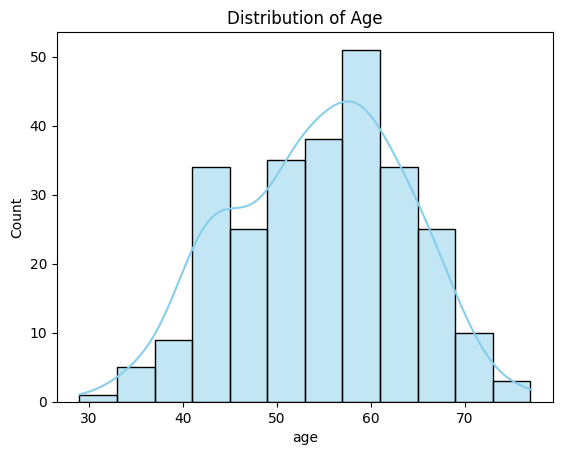

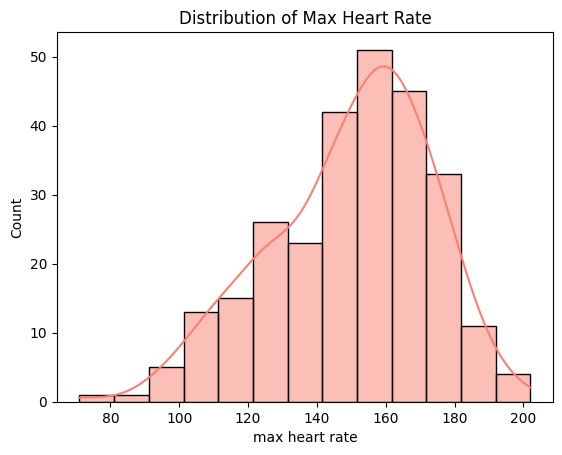

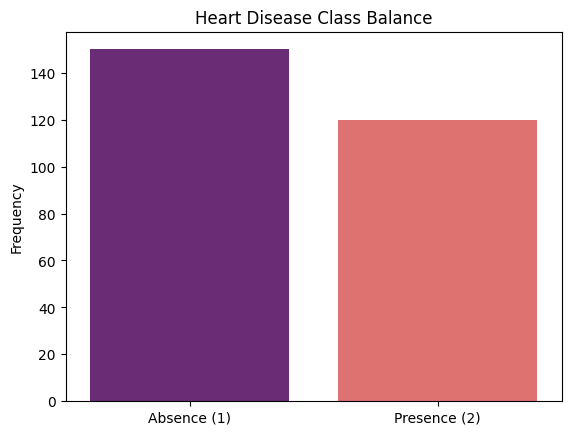

In [6]:
# TODO: pick a few numeric columns and plot histograms


# TODO: plot class balance as a bar chart
import matplotlib.pyplot as plt
import seaborn as sns

# TODO: pick a few numeric columns and plot histograms
numeric_cols = ['age', 'max heart rate']

# Plotting Age Distribution
sns.histplot(df['age'], kde=True, color='skyblue')
plt.title('Distribution of Age')
plt.savefig('hist_age.png')
plt.show()

# Plotting Max Heart Rate Distribution
sns.histplot(df['max heart rate'], kde=True, color='salmon')
plt.title('Distribution of Max Heart Rate')
plt.savefig('hist_max_heart_rate.png')
plt.show()

# TODO: plot class balance as a bar chart
target_counts = df['heart disease'].value_counts().sort_values(ascending=False)
labels = {1: 'Absence (1)', 2: 'Presence (2)'}
x_labels = [labels[i] for i in target_counts.index]

sns.barplot(x=x_labels, y=target_counts.values, hue=x_labels, palette='magma')
plt.title('Heart Disease Class Balance')
plt.ylabel('Frequency')
plt.savefig('class_balance.png')


## Preprocessing pipeline

In [7]:


from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Define categorical and numerical columns
cat_cols = [
    'sex ', 'chest pain type', 'fasting blood sugar',
    'resting electrocardiographic results', 'exercise induced angina',
    'ST segment', 'major vessels', 'thal'
]

num_cols = [
    'age', 'resting blood pressure', 'serum cholestoral',
    'max heart rate', 'oldpeak'
]

# Build the ColumnTransformer
pre = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ]
)



## Helper - evaluation function

In [13]:

import matplotlib.pyplot as plt
import numpy as np

def eval_and_report(name, model, X_test, y_test):
    """Compute metrics and draw confusion matrix and ROC if available."""
    # Predictions
    y_pred = model.predict(X_test)

    # Compute metrics (using pos_label=2 for 'Presence')
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, pos_label=2),
        'recall': recall_score(y_test, y_pred, pos_label=2),
        'f1': f1_score(y_test, y_pred, pos_label=2),
    }

    print(f"Results for {name}:")
    for metric, value in metrics.items():
        print(f"  {metric:10}: {value:.4f}")

    # Confusion matrix plot
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Absence (1)', 'Presence (2)'])
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix: {name}')
    plt.savefig(f'cm_{name.lower().replace(" ", "_")}.png')
    plt.show()

    # ROC curve if model has predict_proba
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
        # Map labels to 0 and 1 for roc_curve (1->0, 2->1)
        y_test_binary = np.where(y_test == 2, 1, 0)
        fpr, tpr, _ = roc_curve(y_test_binary, y_score)
        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], 'k--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'ROC Curve: {name}')
        plt.legend(loc="lower right")
        plt.savefig(f'roc_{name.lower().replace(" ", "_")}.png')
        plt.show()

    return metrics


## Exercise 2 - Logistic Regression without Grid Search

Results for Logistic Regression:
  accuracy  : 0.8704
  precision : 0.8148
  recall    : 0.9167
  f1        : 0.8627


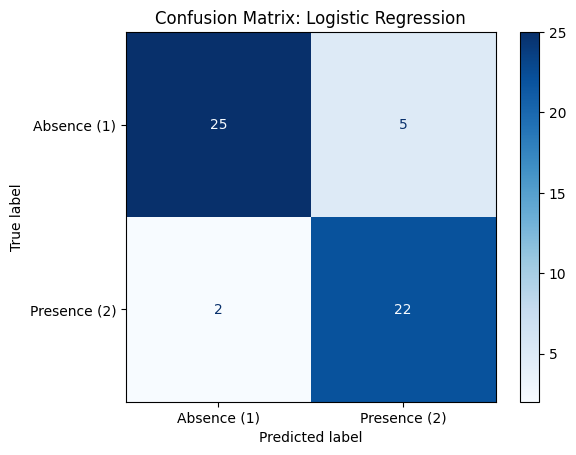

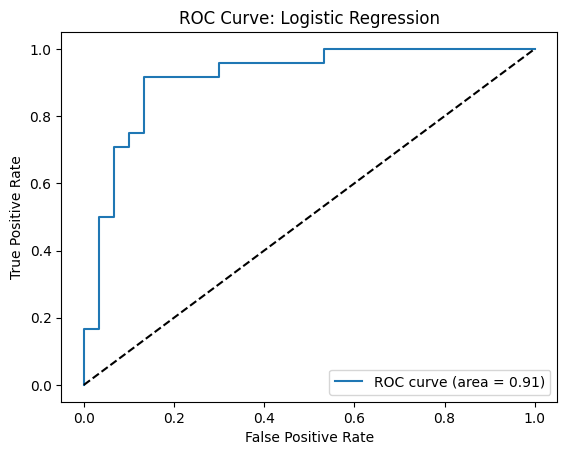

In [14]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,  # <--- This is the missing one
    roc_curve,
    auc
)

# TODO: create a Pipeline with your preprocessor and LogisticRegression
pipe_lr = Pipeline([
    ('preprocessor', pre),
    ('classifier', LogisticRegression(solver='liblinear', max_iter=1000, random_state=RANDOM_STATE))
])

# TODO: fit on training data
pipe_lr.fit(X_train, y_train)

# TODO: evaluate with eval_and_report
lr_no_gs_metrics = eval_and_report("Logistic Regression", pipe_lr, X_test, y_test)


## Exercise 3 - Logistic Regression with Grid Search

Best params: {'lr__C': 0.1, 'lr__penalty': 'l2'}
Results for LR grid:
  accuracy  : 0.8704
  precision : 0.8148
  recall    : 0.9167
  f1        : 0.8627


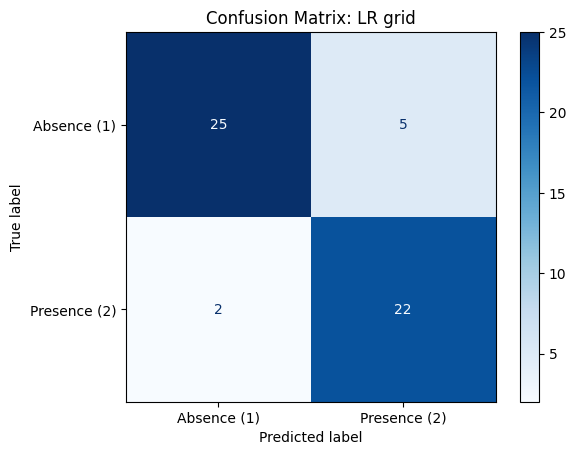

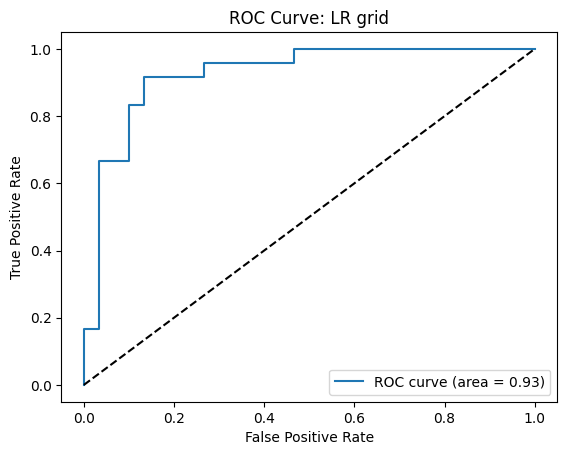

In [15]:
from sklearn.model_selection import GridSearchCV

# TODO: build a Pipeline same as above
pipe_lr_cv = Pipeline([
    ('preprocessor', pre),
    ('lr', LogisticRegression(solver='liblinear', random_state=RANDOM_STATE, max_iter=1000))
])

# TODO: define param_grid for lr__C and lr__penalty
param_grid = {
    'lr__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'lr__penalty': ['l1', 'l2']
}

# TODO: GridSearchCV with cv=5 and scoring='f1'
grid_lr = GridSearchCV(pipe_lr_cv, param_grid, cv=5, scoring='f1')
grid_lr.fit(X_train, y_train)

print('Best params:', grid_lr.best_params_)

# Evaluate the best model
best_lr = grid_lr.best_estimator_
lr_gs_metrics = eval_and_report('LR grid', best_lr, X_test, y_test)

## Exercise 4 - SVM without Grid Search

Results for SVM no grid:
  accuracy  : 0.8519
  precision : 0.7857
  recall    : 0.9167
  f1        : 0.8462


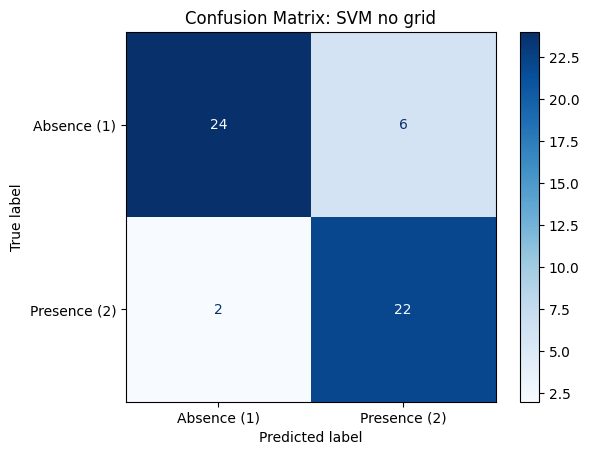

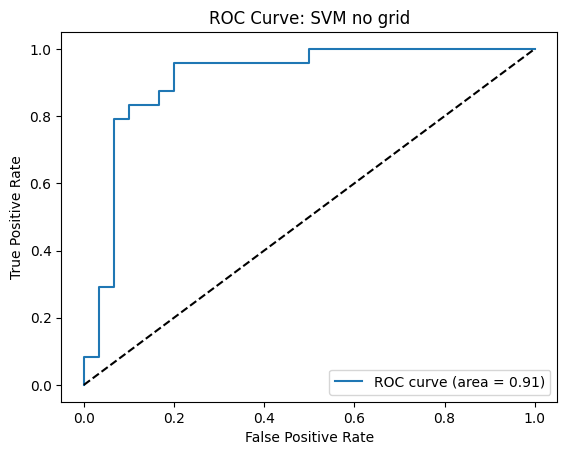

In [16]:
from sklearn.svm import SVC

# TODO: choose kernel and hyperparameters for SVC
pipe_svm = Pipeline([
    ('preprocessor', pre),
    ('svc', SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=RANDOM_STATE))
])

# TODO: fit on training data
pipe_svm.fit(X_train, y_train)

# TODO: evaluate with eval_and_report
svm_no_metrics = eval_and_report('SVM no grid', pipe_svm, X_test, y_test)

## Exercise 5 - SVM with Grid Search

Best params: {'svm__C': 10, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}
Results for SVM grid:
  accuracy  : 0.8704
  precision : 0.8148
  recall    : 0.9167
  f1        : 0.8627


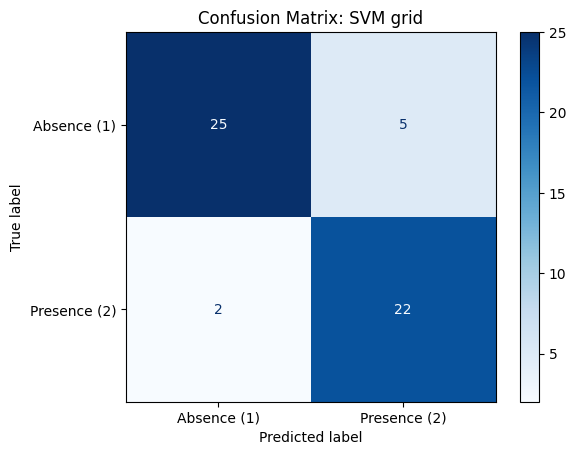

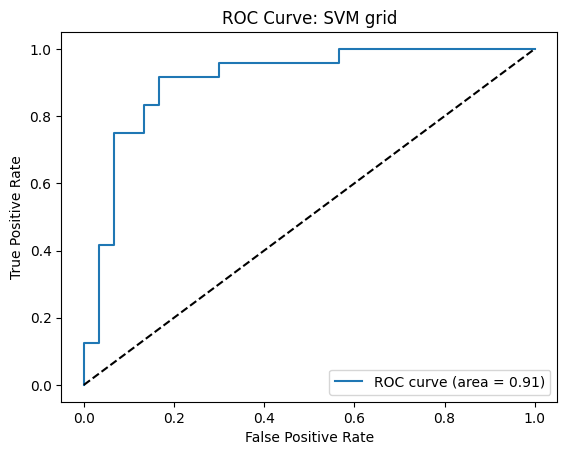

In [17]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

# TODO: Pipeline with SVC(probability=True) so you can plot ROC
pipe_svm_cv = Pipeline([
    ('preprocessor', pre),
    ('svm', SVC(probability=True, random_state=RANDOM_STATE))
])

# TODO: param_grid with svm__kernel, svm__C, svm__gamma
svm_param_grid = {
    'svm__kernel': ['rbf', 'linear'],
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 'auto', 0.01, 0.1]
}

# TODO: GridSearchCV, fit, evaluate best estimator
grid_svm = GridSearchCV(pipe_svm_cv, svm_param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_svm.fit(X_train, y_train)

print(f"Best params: {grid_svm.best_params_}")

# Evaluate the best model
best_svm = grid_svm.best_estimator_
svm_gs_metrics = eval_and_report('SVM grid', best_svm, X_test, y_test)


## Exercise 6 - XGBoost without Grid Search

Results for Gradient Boosting:
  accuracy  : 0.8333
  precision : 0.7778
  recall    : 0.8750
  f1        : 0.8235


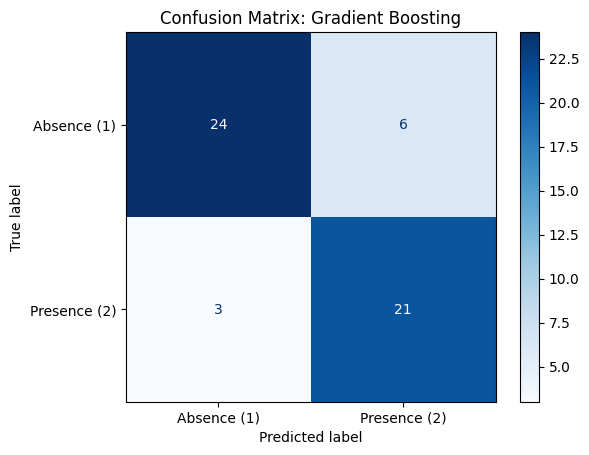

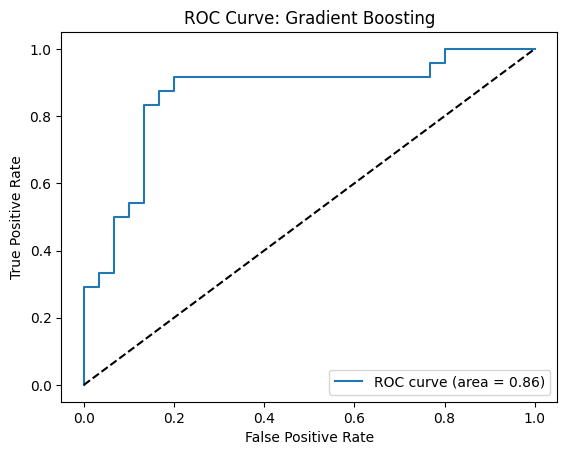

In [20]:
from sklearn.ensemble import GradientBoostingClassifier

# TODO: build a Pipeline with your preprocessor and GradientBoostingClassifier
pipe_gb = Pipeline([
    ('preprocessor', pre),
    ('gb', GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=3,
        random_state=RANDOM_STATE
    ))
])

# TODO: fit on training data
pipe_gb.fit(X_train, y_train)

# TODO: evaluate with eval_and_report
gb_no_metrics = eval_and_report('Gradient Boosting', pipe_gb, X_test, y_test)

## Exercise 7 - XGBoost with Grid Search

Best params: {'gb__learning_rate': 0.1, 'gb__max_depth': 5, 'gb__n_estimators': 200, 'gb__subsample': 0.8}
Results for GB grid:
  accuracy  : 0.8519
  precision : 0.8333
  recall    : 0.8333
  f1        : 0.8333


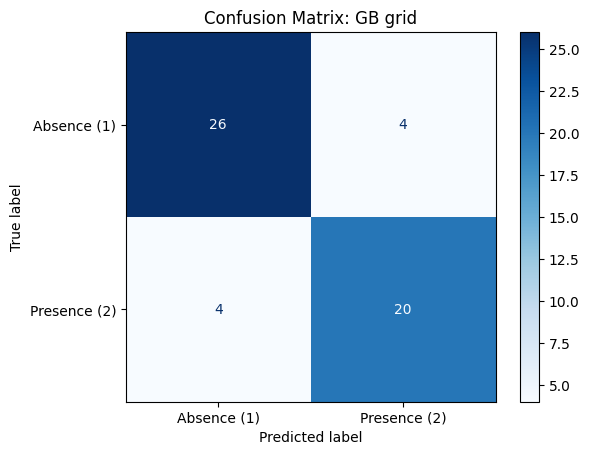

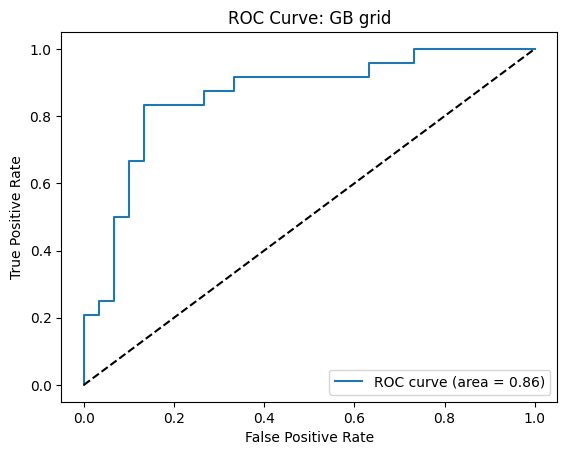

In [21]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier

# TODO: Pipeline with GradientBoostingClassifier
pipe_gb_cv = Pipeline([
    ('preprocessor', pre),
    ('gb', GradientBoostingClassifier(random_state=RANDOM_STATE))
])

# TODO: define a reasonable param_grid
gb_param_grid = {
    'gb__n_estimators': [100, 200, 300],
    'gb__learning_rate': [0.01, 0.1, 0.2],
    'gb__max_depth': [3, 4, 5],
    'gb__subsample': [0.8, 1.0]
}

# TODO: GridSearchCV, fit, evaluate best estimator
grid_gb = GridSearchCV(pipe_gb_cv, gb_param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_gb.fit(X_train, y_train)

print(f"Best params: {grid_gb.best_params_}")

# Evaluate the best model
best_gb = grid_gb.best_estimator_
gb_gs_metrics = eval_and_report('GB grid', best_gb, X_test, y_test)


## Compare models

--- Comparaison des Modèles ---
              accuracy  precision    recall        f1
LR Baseline   0.870370   0.814815  0.916667  0.862745
LR Tuned      0.870370   0.814815  0.916667  0.862745
SVM Baseline  0.851852   0.785714  0.916667  0.846154
SVM Tuned     0.870370   0.814815  0.916667  0.862745
GB Baseline   0.833333   0.777778  0.875000  0.823529
GB Tuned      0.851852   0.833333  0.833333  0.833333


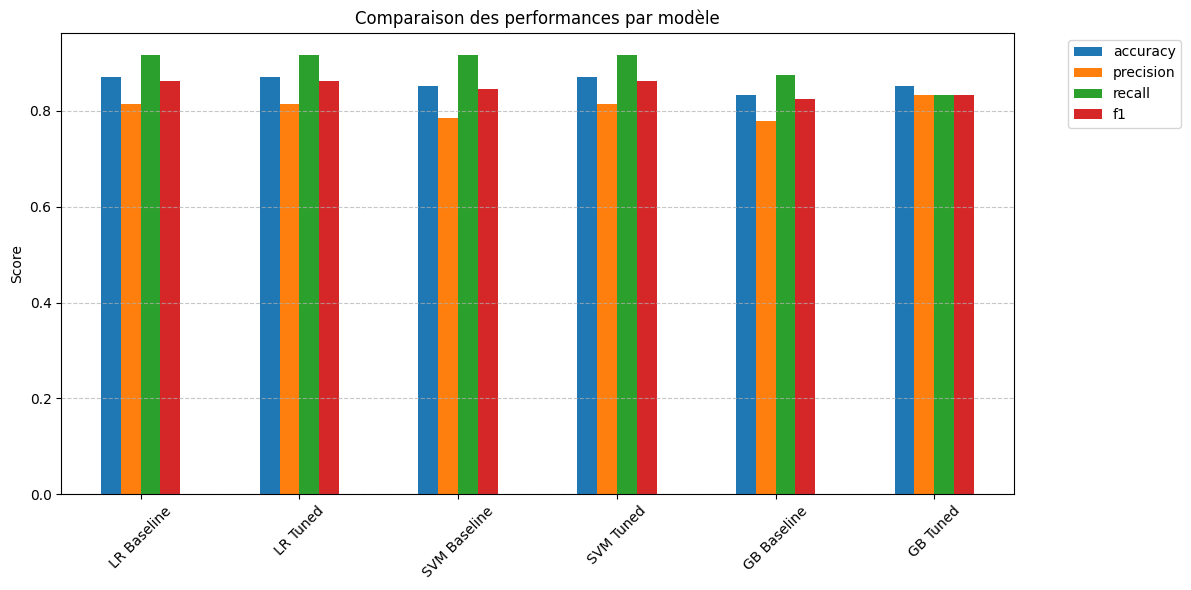

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Rassemblement des métriques dans un dictionnaire
summary = {
    'LR Baseline': lr_no_gs_metrics,
    'LR Tuned': lr_gs_metrics,
    'SVM Baseline': svm_no_metrics,
    'SVM Tuned': svm_gs_metrics,
    'GB Baseline': gb_no_metrics,
    'GB Tuned': gb_gs_metrics
}

# 2. Création du DataFrame de comparaison
# orient='index' place les modèles en lignes et les métriques en colonnes
df_comparison = pd.DataFrame.from_dict(summary, orient='index')

# Affichage du tableau
print("--- Comparaison des Modèles ---")
print(df_comparison)

# 3. Visualisation graphique (Optionnel mais recommandé)
df_comparison.plot(kind='bar', figsize=(12, 6))
plt.title('Comparaison des performances par modèle')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Exportation des résultats
df_comparison.to_csv('model_comparison.csv')